Loading of libraries and connecting to my MySQL server

In [75]:
from dotenv import load_dotenv
import os
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [ ]:
load_dotenv()

conn = mysql.connector.connect(
    host="localhost",
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database="uk_accidents"
)

Change of format of time columns for better analysis

In [ ]:
cursor = conn.cursor()

cursor.execute("CREATE TEMPORARY TABLE IF NOT EXISTS uk_temp AS (SELECT * FROM uk_accidents)");

#Change columns formats to better illustrate the data
cursor.execute("ALTER TABLE uk_temp MODIFY COLUMN Time time");
cursor.execute("ALTER TABLE uk_temp ADD Date_ISO date; ");
cursor.execute("UPDATE uk_temp SET Date_ISO = str_to_date(Date, '%d/%m/%Y')");
cursor.execute("ALTER TABLE uk_temp MODIFY COLUMN Date_ISO date"); 

Analyzing casualties and accidents per speed limit

In [73]:
query = '''SELECT speed_limit, COUNT(*) AS accidents_per_speed, SUM(Number_of_Casualties) AS death_per_speed FROM uk_temp 
GROUP BY speed_limit ORDER BY speed_limit;
;'''
df = pd.read_sql(query, conn)
df

C:\Users\asusg\AppData\Local\Temp\ipykernel_13408\1897206623.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,speed_limit,accidents_per_speed,death_per_speed
0,10,14,17.0
1,15,10,11.0
2,20,17157,20196.0
3,30,968284,1229007.0
4,40,122393,175792.0
5,50,48790,73530.0
6,60,238234,361676.0
7,70,109268,171817.0


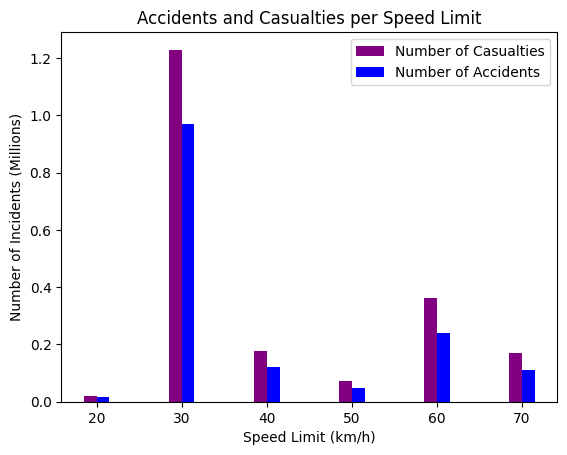

In [76]:
# Speed limits below 20 km/h does not produce meaningful result, thus they are ignored in the graph.
df = df[df['speed_limit'] >= 20]
x = df['speed_limit']
casualties = df['death_per_speed'] / 1e6
accidents = df['accidents_per_speed'] / 1e6

plt.bar(x, casualties, label='Number of Casualties', color= "purple", width=-1.5, align='edge')
plt.bar(x, accidents, label='Number of Accidents', color= "blue", align='edge', width=1.5)
plt.xlabel('Speed Limit (km/h)')
plt.ylabel('Number of Incidents (Millions)')
plt.title('Accidents and Casualties per Speed Limit')
plt.legend()
plt.show()

Against common sense, most accidents happened in streets with 30 km/h speed limits, rather than streets with higher ones.

Analyzing casualties and accidents per hour

In [77]:
query = '''SELECT EXTRACT(HOUR FROM Time) AS hour,
COUNT(*) AS accidents_per_hour , SUM(Number_of_Casualties) casualties_per_hour FROM uk_temp
WHERE Time IS NOT NULL
GROUP BY hour  ORDER BY hour;
;'''
df = pd.read_sql(query, conn)
df

C:\Users\asusg\AppData\Local\Temp\ipykernel_13408\2387440958.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,hour,accidents_per_hour,casualties_per_hour
0,0,23025,33054.0
1,1,16890,24027.0
2,2,13618,19413.0
3,3,10827,15381.0
4,4,8347,11546.0
5,5,12035,15819.0
6,6,25832,32557.0
7,7,62374,78114.0
8,8,109622,139893.0
9,9,74901,96586.0


It can be clearly seen that the casualties per hour are always higher than the accidents per hour.

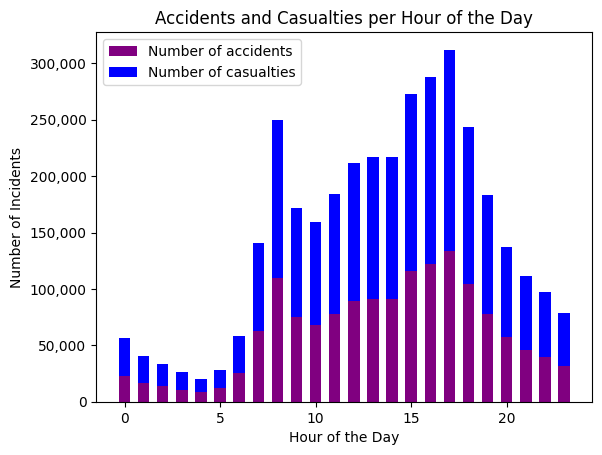

In [78]:
x = df['hour']
casualties = df['casualties_per_hour']
accidents = df['accidents_per_hour']

plt.bar(x, accidents, color= "purple", width=0.6, label='Number of accidents')
plt.bar(x, bottom=accidents, height=casualties, color= "blue", width=0.6, label='Number of casualties')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Incidents')
plt.title('Accidents and Casualties per Hour of the Day')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.legend()
plt.show()

It can be inferred from the graph that the peaks are at the times in which people are coming or going to work (8,15,16,17 hours).

Analyzing casualties and accidents per year

In [79]:
query = '''SELECT YEAR(Date_ISO) AS year,
COUNT(*) AS accidents_per_year , SUM(Number_of_Casualties) casualties_per_year FROM uk_temp
GROUP BY YEAR(Date_ISO) ORDER BY YEAR(Date_ISO);'''
df = pd.read_sql(query, conn)
df

C:\Users\asusg\AppData\Local\Temp\ipykernel_13408\4022571510.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,year,accidents_per_year,casualties_per_year
0,2005,198735,271017.0
1,2006,189161,258404.0
2,2007,182115,247780.0
3,2009,163554,222146.0
4,2010,154414,208648.0
5,2011,151474,203950.0
6,2012,179715,241954.0
7,2013,138660,183670.0
8,2014,146322,194477.0


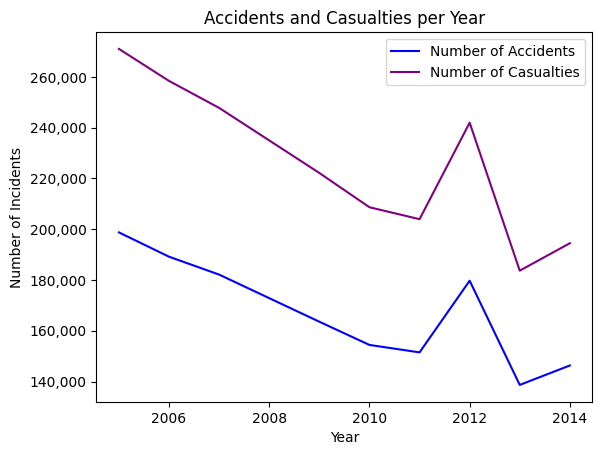

In [80]:
plt.plot(df['year'], df['accidents_per_year'], label='Number of Accidents', color='blue')
plt.plot(df['year'], df['casualties_per_year'], label='Number of Casualties', color='purple')
plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.title('Accidents and Casualties per Year')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.legend()
plt.show()

It can be observed a steep decline in roads accidents throughout 2005-2011, until it has a peak in 2012. After which
the situation can be seen to normalize.